<a href="https://colab.research.google.com/github/NegasaReta/Elevvo-Internship-Machine-Learning-Track/blob/Task1/Bonus1_implementation_student_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import important Libraries first

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


##Load the dataset

In [4]:
CSV_PATH = "/content/StudentPerformanceFactors.csv"
FEATURE_COL = "Hours_Studied"
TARGET_COL = "Exam_Score"


df = pd.read_csv(CSV_PATH)

In [5]:
df.head ()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
data = df[[FEATURE_COL, TARGET_COL]].copy()

data[FEATURE_COL] = pd.to_numeric(data[FEATURE_COL], errors="coerce")
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors="coerce")
data = data.dropna()

X = data[[FEATURE_COL]].values
y = data[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##Metrics

In [7]:

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

results = []


In [8]:
# Degree 1 (same as standard linear regression)
for deg in [1, 2, 3, 4, 5]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae, mse, rmse, r2 = metrics(y_test, y_pred)
    results.append((deg, mae, mse, rmse, r2))

In [9]:

# Print comparison table
print("Polynomial Regression (Hours_Studied only) - Test Set Metrics")
print("degree\tMAE\t\tMSE\t\tRMSE\t\tR2")
for deg, mae, mse, rmse, r2 in results:
    print(f"{deg}\t{mae:.4f}\t{mse:.4f}\t{rmse:.4f}\t{r2:.4f}")

best = max(results, key=lambda x: x[-1])  # best R2
print(f"\nBest by R2: degree={best[0]} with R2={best[4]:.4f} and RMSE={best[3]:.4f}")

Polynomial Regression (Hours_Studied only) - Test Set Metrics
degree	MAE		MSE		RMSE		R2
1	2.4476	10.8559	3.2948	0.2320
2	2.4448	10.8450	3.2932	0.2328
3	2.4445	10.8438	3.2930	0.2328
4	2.4455	10.8607	3.2956	0.2317
5	2.4455	10.8612	3.2956	0.2316

Best by R2: degree=3 with R2=0.2328 and RMSE=3.2930


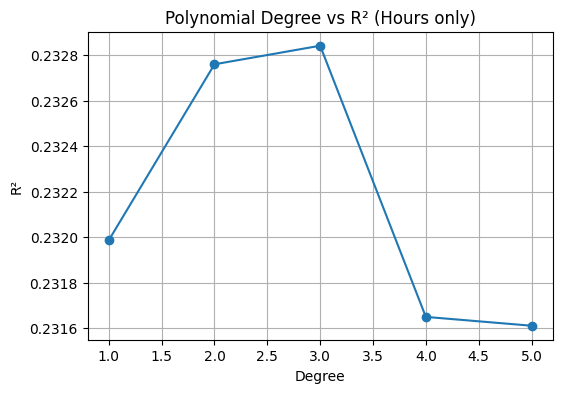

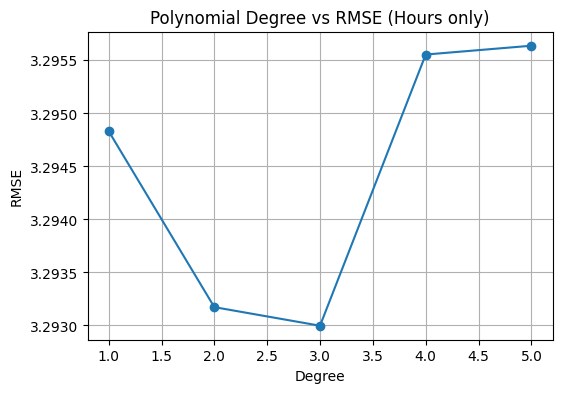

In [13]:


poly_df = pd.DataFrame(results, columns=['degree', 'MAE', 'MSE', 'RMSE', 'R2'])

plt.figure(figsize=(6,4))
plt.plot(poly_df["degree"], poly_df["R2"], marker="o")
plt.title("Polynomial Degree vs R² (Hours only)")
plt.xlabel("Degree"); plt.ylabel("R²")
plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(poly_df["degree"], poly_df["RMSE"], marker="o")
plt.title("Polynomial Degree vs RMSE (Hours only)")
plt.xlabel("Degree"); plt.ylabel("RMSE")
plt.grid(True); plt.show()

## Bonus 1: Polynomial Regression (Hours_Studied → Exam_Score)

### Test-set comparison (degrees 1–5)

| Degree | MAE | MSE | RMSE | R² |
|---:|---:|---:|---:|---:|
| 1 (Linear) | 2.4476 | 10.8559 | 3.2948 | 0.2320 |
| 2 | 2.4448 | 10.8450 | 3.2932 | 0.2328 |
| 3 | 2.4445 | 10.8438 | 3.2930 | 0.2328 |
| 4 | 2.4455 | 10.8607 | 3.2956 | 0.2317 |
| 5 | 2.4455 | 10.8612 | 3.2956 | 0.2316 |

### Best degree
- The best model by **R²** is **degree = 3**, with **R² = 0.2328** and **RMSE = 3.2930**.

### Interpretation
- Polynomial regression provides only a **very small improvement** over linear regression (R²: **0.2320 → 0.2328**, RMSE: **3.2948 → 3.2930**).
- This suggests the relationship between `Hours_Studied` and `Exam_Score` is **mostly linear** (or that `Hours_Studied` alone does not contain enough information to capture most score variation).
- Higher degrees (4–5) slightly **worsen** performance, indicating **no benefit** from more complex curves and possible mild overfitting.